# 02. Baseline — LightGBM (전체 피처)

- 피처: 전체 67개
- 전처리: 순서형 정수 매핑 / 명목형 Label Encoding / 배아생성이유 멀티핫
- 모델: LightGBM
- 평가: Stratified 5-Fold ROC-AUC

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

warnings.filterwarnings('ignore')
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path('../data/raw')
OUT_DIR  = Path('../data/submissions')
DOCS_DIR = Path('../docs')
TARGET   = '임신 성공 여부'
ID_COL   = 'ID'
SEED     = 42
N_FOLDS  = 5

# ── 실험 메타데이터 ──────────────────────────────────────────────────────────
EXP_NO      = 2
AUTHOR      = '조여진'
MODEL_NAME  = 'LightGBM'
CV_STR      = f'Stratified {N_FOLDS}-Fold'
KEY_CHANGES = 'Baseline: 전체 67 피처, 순서형/명목형/멀티핫 인코딩'

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
sub   = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'train: {train.shape}  /  test: {test.shape}')

train: (256351, 69)  /  test: (90067, 68)


## 1. 전처리

In [2]:
# ── 순서형 매핑 ──────────────────────────────────────────
COUNT_ORDER     = ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']
AGE_ORDER       = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
DONOR_AGE_ORDER = ['만20세 이하', '만21-25세', '만26-30세', '만31-35세', '만36-40세', '만41-45세', '알 수 없음']

ORDINAL_COLS = {
    '시술 당시 나이'         : AGE_ORDER,
    '난자 기증자 나이'        : DONOR_AGE_ORDER,
    '정자 기증자 나이'        : DONOR_AGE_ORDER,
    '총 시술 횟수'           : COUNT_ORDER,
    '클리닉 내 총 시술 횟수'  : COUNT_ORDER,
    'IVF 시술 횟수'          : COUNT_ORDER,
    'DI 시술 횟수'           : COUNT_ORDER,
    '총 임신 횟수'           : COUNT_ORDER,
    'IVF 임신 횟수'          : COUNT_ORDER,
    'DI 임신 횟수'           : COUNT_ORDER,
    '총 출산 횟수'           : COUNT_ORDER,
    'IVF 출산 횟수'          : COUNT_ORDER,
    'DI 출산 횟수'           : COUNT_ORDER,
}

# ── 명목형 Label Encoding ────────────────────────────────
LABEL_COLS = ['시술 시기 코드', '시술 유형', '특정 시술 유형', '배란 유도 유형', '난자 출처', '정자 출처']

# ── 배아 생성 주요 이유 멀티핫 ───────────────────────────
EMBRYO_REASONS = ['기증용', '난자 저장용', '배아 저장용', '연구용', '현재 시술용']
EMBRYO_COL     = '배아 생성 주요 이유'

print('순서형:', len(ORDINAL_COLS), '개')
print('명목형:', len(LABEL_COLS), '개')
print('멀티핫:', EMBRYO_COL)

순서형: 13 개
명목형: 6 개
멀티핫: 배아 생성 주요 이유


In [3]:
# 상수 컬럼 (전체가 동일한 값 → 피처 의미 없음)
CONST_COLS = ['착상 전 유전 검사 사용 여부', 'PGD 시술 여부', '불임 원인 - 여성 요인']

def preprocess(train_df, test_df):
    tr = train_df.drop(columns=[ID_COL, TARGET] + CONST_COLS).copy()
    te = test_df.drop(columns=[ID_COL] + CONST_COLS).copy()

    # 1. 순서형 정수 매핑
    for col, order in ORDINAL_COLS.items():
        mapping = {v: i for i, v in enumerate(order)}
        tr[col] = tr[col].map(mapping)
        te[col] = te[col].map(mapping)

    # 2. 명목형 LabelEncoding (train+test 합쳐서 fit)
    for col in LABEL_COLS:
        le = LabelEncoder()
        combined = pd.concat([tr[col], te[col]], ignore_index=True).astype(str)
        le.fit(combined)
        tr[col] = le.transform(tr[col].astype(str))
        te[col] = le.transform(te[col].astype(str))

    # 3. 배아 생성 주요 이유 멀티핫
    for reason in EMBRYO_REASONS:
        col_name = f'배아이유_{reason}'
        tr[col_name] = tr[EMBRYO_COL].fillna('').str.contains(reason).astype(int)
        te[col_name] = te[EMBRYO_COL].fillna('').str.contains(reason).astype(int)
    tr.drop(columns=[EMBRYO_COL], inplace=True)
    te.drop(columns=[EMBRYO_COL], inplace=True)

    return tr, te

X_train, X_test = preprocess(train, test)
y_train = train[TARGET]

print(f'X_train: {X_train.shape}  /  X_test: {X_test.shape}')
print(f'결측 컬럼 수: {X_train.isnull().any().sum()}개  (LightGBM NaN 자동 처리)')

X_train: (256351, 68)  /  X_test: (90067, 68)
결측 컬럼 수: 27개  (LightGBM NaN 자동 처리)


## 2. 5-Fold 교차검증

In [4]:
LGB_PARAMS = dict(
    objective         = 'binary',
    metric            = 'auc',
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 1,
    lambda_l1         = 0.1,
    lambda_l2         = 0.1,
    is_unbalance      = True,   # 클래스 불균형 보정
    verbosity         = -1,
    seed              = SEED,
)

skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_aucs  = []
models     = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    ds_tr  = lgb.Dataset(X_tr,  label=y_tr)
    ds_val = lgb.Dataset(X_val, label=y_val, reference=ds_tr)

    model = lgb.train(
        LGB_PARAMS,
        ds_tr,
        num_boost_round = 2000,
        valid_sets      = [ds_val],
        callbacks       = [
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    val_prob = model.predict(X_val)
    auc      = roc_auc_score(y_val, val_prob)
    fold_aucs.append(auc)
    oof_preds[val_idx] = val_prob
    test_preds        += model.predict(X_test) / N_FOLDS
    models.append(model)

    print(f'  Fold {fold}  best_iter={model.best_iteration:4d}  AUC={auc:.5f}')

oof_auc = roc_auc_score(y_train, oof_preds)
print()
print(f'OOF ROC-AUC : {oof_auc:.5f}')
print(f'Fold 평균   : {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}')

  Fold 1  best_iter= 146  AUC=0.73688
  Fold 2  best_iter= 101  AUC=0.74211
  Fold 3  best_iter=  57  AUC=0.73940
  Fold 4  best_iter=  72  AUC=0.73798
  Fold 5  best_iter=  82  AUC=0.74024

OOF ROC-AUC : 0.73910
Fold 평균   : 0.73932 ± 0.00181


## 3. 결과 시각화

Matplotlib is building the font cache; this may take a moment.


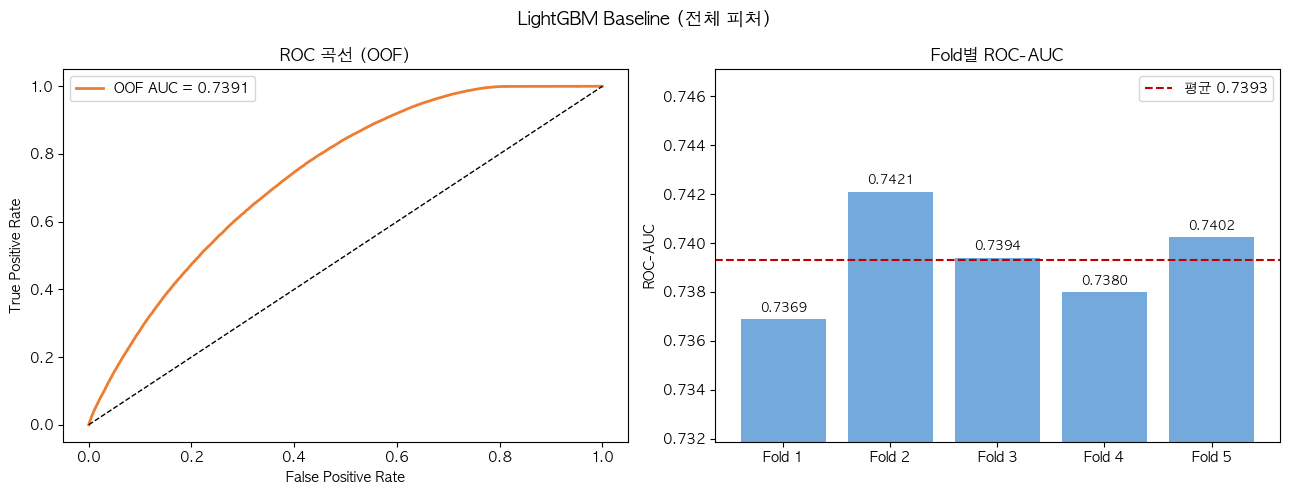

In [5]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC 곡선
fpr, tpr, _ = roc_curve(y_train, oof_preds)
axes[0].plot(fpr, tpr, color='#ED7D31', lw=2, label=f'OOF AUC = {oof_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC 곡선 (OOF)')
axes[0].legend()

# Fold별 AUC
axes[1].bar([f'Fold {i}' for i in range(1, N_FOLDS+1)], fold_aucs, color='#5B9BD5', alpha=0.85)
axes[1].axhline(np.mean(fold_aucs), color='#C00000', linestyle='--', label=f'평균 {np.mean(fold_aucs):.4f}')
axes[1].set_ylim(min(fold_aucs) - 0.005, max(fold_aucs) + 0.005)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Fold별 ROC-AUC')
axes[1].legend()
for i, v in enumerate(fold_aucs):
    axes[1].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('LightGBM Baseline (전체 피처)', fontsize=13)
plt.tight_layout()
plt.show()

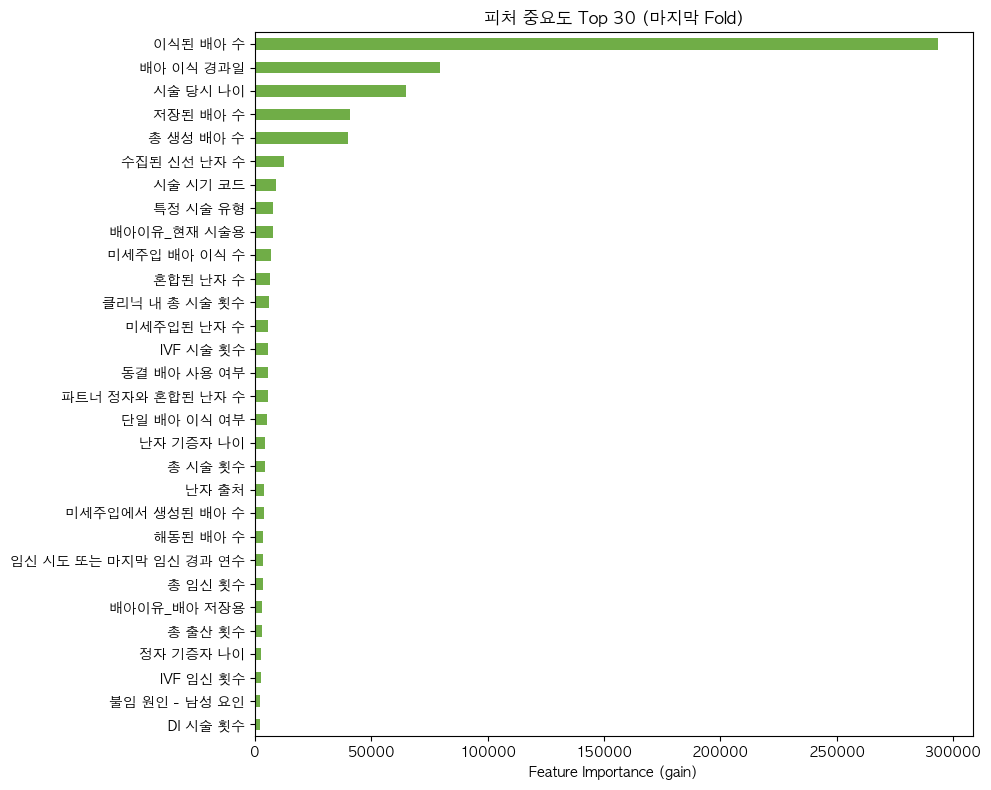

In [6]:
# 피처 중요도 Top 30
importance = pd.Series(
    models[-1].feature_importance(importance_type='gain'),
    index=X_train.columns
).sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
importance[::-1].plot(kind='barh', ax=ax, color='#70AD47')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('피처 중요도 Top 30 (마지막 Fold)')
plt.tight_layout()
plt.show()

## 4. Submission 저장

In [7]:
sub['probability'] = test_preds

auc_str  = f'{oof_auc:.4f}'.replace('.', '')
out_fname = f'submission_exp{EXP_NO:03d}_{AUTHOR}_{auc_str}.csv'
out_path  = OUT_DIR / out_fname
sub.to_csv(out_path, index=False)

print(f'저장: {out_path}')
print()
print(sub['probability'].describe().round(4))
sub.head()

저장: ../data/submissions/submission_exp002_yjc_07391.csv

count    90067.0000
mean         0.4454
std          0.2326
min          0.0069
25%          0.3166
50%          0.5079
75%          0.6254
max          0.8422
Name: probability, dtype: float64


,ID,probability
0,TEST_00000,0.010235
1,TEST_00001,0.007565
2,TEST_00002,0.333786
3,TEST_00003,0.246205
4,TEST_00004,0.749147


## 5. 결과 요약

In [8]:
print('=' * 45)
print('  LightGBM Baseline 결과')
print('=' * 45)
print(f'  피처 수        : {X_train.shape[1]}개')
print(f'  OOF ROC-AUC   : {oof_auc:.5f}')
print(f'  Fold 평균 AUC : {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}')
print('=' * 45)

  LightGBM Baseline 결과
  피처 수        : 68개
  OOF ROC-AUC   : 0.73910
  Fold 평균 AUC : 0.73932 ± 0.00181


In [9]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from datetime import date

# ── threshold=0.5 기준 분류 지표 계산 (참고용) ───────────────────────────────
oof_binary = (oof_preds >= 0.5).astype(int)
f1        = f1_score(y_train, oof_binary)
recall    = recall_score(y_train, oof_binary)
precision = precision_score(y_train, oof_binary)
accuracy  = accuracy_score(y_train, oof_binary)

print('[OOF 분류 지표 — threshold=0.5]')
print(f'  AUC-ROC   : {oof_auc:.5f}  ← 대회 평가 지표')
print(f'  F1        : {f1:.5f}')
print(f'  Recall    : {recall:.5f}')
print(f'  Precision : {precision:.5f}')
print(f'  Accuracy  : {accuracy:.5f}')
print()

# ── 실험 기록 설정 (실험마다 수정) ───────────────────────────────────────────
PREPROCESSING_VER = 'v1'
IMBALANCE_METHOD  = 'is_unbalance=True'
SUBMITTED         = 'N'     # 제출 후 Y로 변경
HACKATHON_SCORE   = None    # 제출 후 직접 입력
NOTES           = '전체 피처 68개, 순서형/명목형/멀티핫 인코딩. 기준점 실험'
INSIGHTS        = '클래스 불균형 2.87:1. is_unbalance=True 적용. OOF 0.73887 기준점 확보'

params_str = (f"num_leaves={LGB_PARAMS['num_leaves']}, "
              f"lr={LGB_PARAMS['learning_rate']}, "
              f"feature_fraction={LGB_PARAMS['feature_fraction']}, "
              f"lambda_l1={LGB_PARAMS['lambda_l1']}")


def log_to_leaderboard(exp_no, author, model_name, params_str,
                        f1, recall, precision, accuracy, oof_auc,
                        cv_strategy, preprocessing_ver, n_features,
                        imbalance_method, submitted, hackathon_score,
                        file_name, notes='', insights=''):

    lb_path = DOCS_DIR / 'leaderboard.xlsx'
    wb = load_workbook(lb_path)
    ws = wb['리더보드']

    exp_label = f'EXP-{exp_no:03d}'
    next_row = ws.max_row + 1
    for r in range(2, ws.max_row + 1):
        val = ws.cell(row=r, column=2).value  # B열: 회차
        if val == exp_label:
            next_row = r  # 같은 회차 → 덮어쓰기
            break
        if ws.cell(row=r, column=1).value is None or str(ws.cell(row=r, column=1).value).strip() == '':
            next_row = r  # 빈 행 → 새 행 추가
            break

    values = [
        str(date.today()),    # 날짜
        f'EXP-{exp_no:03d}',  # 회차
        author,               # 팀원
        model_name,           # 모델명
        params_str,           # 주요파라미터
        round(f1, 5),         # F1 score
        round(recall, 5),     # Recall
        round(precision, 5),  # Precision
        round(accuracy, 5),   # Accuracy
        round(oof_auc, 5),    # AUC-ROC
        cv_strategy,          # 검증 방법
        preprocessing_ver,    # 전처리 버전
        n_features,           # 사용 피처 수
        imbalance_method,     # 클래스 불균형 처리
        submitted,            # 해커톤 제출 여부
        hackathon_score,      # 해커톤 점수
        file_name,            # 파일 경로링크
        notes,                # 특이사항
        insights,             # 인사이트
    ]

    thin   = Side(style='thin', color='B0B8D0')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    fill   = PatternFill('solid', fgColor='EEF2FA') if next_row % 2 == 0 else None
    font   = Font(name='맑은 고딕', size=10)
    center = Alignment(horizontal='center', vertical='center', wrap_text=True)
    left   = Alignment(horizontal='left',   vertical='center', wrap_text=True)
    left_cols = {4, 5, 12, 14, 17, 18, 19}

    for c_idx, val in enumerate(values, start=1):
        cell = ws.cell(row=next_row, column=c_idx, value=val)
        cell.font      = font
        cell.border    = border
        cell.alignment = left if c_idx in left_cols else center
        if fill:
            cell.fill = fill
        if c_idx in range(6, 11) or c_idx == 16:
            cell.number_format = '0.00000'

    wb.save(lb_path)
    print(f'[leaderboard.xlsx] EXP-{exp_no:03d} 기록 완료 (row {next_row})')
    print(f'  AUC-ROC : {oof_auc:.5f}  |  파일: {file_name}')
    print(f'  해커톤 점수: 제출 후 직접 입력')


log_to_leaderboard(
    exp_no           = EXP_NO,
    author           = AUTHOR,
    model_name       = MODEL_NAME,
    params_str       = params_str,
    f1               = f1,
    recall           = recall,
    precision        = precision,
    accuracy         = accuracy,
    oof_auc          = oof_auc,
    cv_strategy      = CV_STR,
    preprocessing_ver= PREPROCESSING_VER,
    n_features       = X_train.shape[1],
    imbalance_method = IMBALANCE_METHOD,
    submitted        = SUBMITTED,
    hackathon_score  = HACKATHON_SCORE,
    file_name        = 'notebooks/02_baseline_yjcho.ipynb',
    notes            = NOTES,
    insights         = INSIGHTS,
)

[OOF 분류 지표 — threshold=0.5]
  AUC-ROC   : 0.73910  ← 대회 평가 지표
  F1        : 0.51684
  Recall    : 0.77259
  Precision : 0.38831
  Accuracy  : 0.62682

[leaderboard.xlsx] EXP-002 기록 완료 (row 2)
  AUC-ROC : 0.73910  |  파일: submission_exp002_yjc_07391.csv
  해커톤 점수: 제출 후 직접 입력


## 6. 자동 실험 기록 → `docs/leaderboard.xlsx`

- **해커톤 점수**는 제출 후 직접 입력
- **인사이트/특이사항**은 셀 상단 변수에 미리 작성 후 실행